# Injector Surrogate Model Example

This notebook demonstrates the use of the InjectorSurrogate model from the virtual-accelerator package. The injector surrogate is a machine learning model that approximates the behavior of an electron beam injector, allowing for fast simulation of beam dynamics without running expensive physics simulations.

## Model Setup

First, we import the necessary libraries and create an instance of the InjectorSurrogate model:

In [1]:
from virtual_accelerator.surrogates.injector_surrogate import InjectorSurrogate
import matplotlib.pyplot as plt

model = InjectorSurrogate()

/Users/smiskov/miniconda3/envs/va-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Setting Accelerator Parameters

The surrogate model allows us to set various accelerator parameters and observe their effects on the beam. Here we set the control value for quadrupole magnet `QUAD:IN20:525:BCTRL` to -5.0.

In [2]:
model.set({"QUAD:IN20:525:BCTRL": -5.0})

## Visualizing the Output Beam

After setting the quadrupole strength, we can retrieve the output beam from the model and visualize its transverse distribution. The `output_beam` contains particle positions and momenta. We plot the x vs y positions to see the spatial distribution of electrons in the beam.

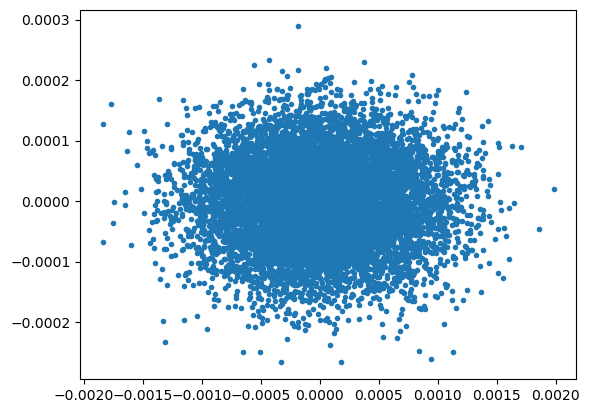

In [3]:
fig, ax = plt.subplots()
beam = model.get(["output_beam"])["output_beam"]
ax.plot(beam.x, beam.y, ".")

## Quadrupole Scan Analysis

Now we perform a systematic scan of the quadrupole magnet strength to study how it affects the beam. 

We'll:
1. Vary the quadrupole strength from -10 to +3
2. For each setting, plot the beam distribution
3. Track the RMS beam sizes at a downstream screen (`OTRS:IN20:571`)
4. Plot how the beam sizes change with quadrupole strength

This demonstrates the surrogate model's ability to quickly simulate parameter scans that would take much longer with full physics simulations.

<Axes: xlabel='QUAD:IN20:525:BCTRL'>

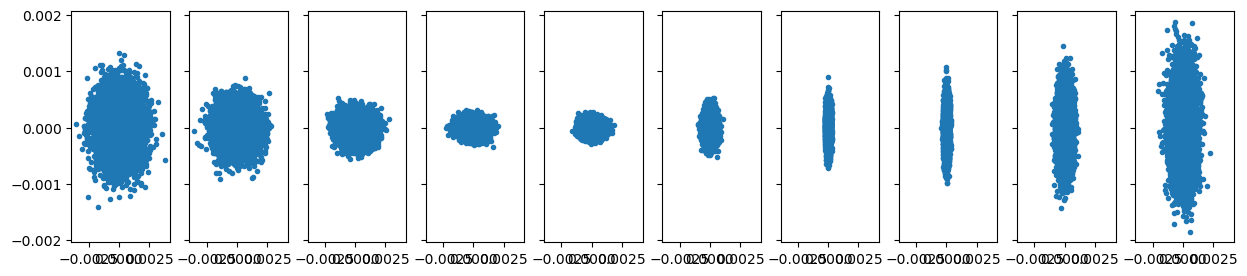

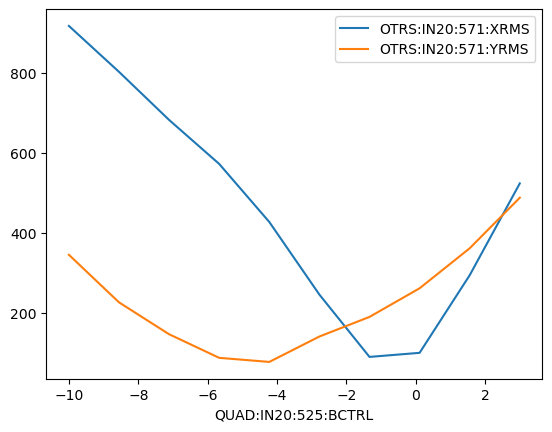

In [4]:
# do a quadrupole scan and plot how the distribution changes
import numpy as np
import pandas as pd

quad_values = np.linspace(-10, 3, 10)

fig, ax = plt.subplots(1, len(quad_values), figsize=(15, 3), sharex=True, sharey=True)
fig2, ax2 = plt.subplots()

rms_sizes = []
for i, quad_value in enumerate(quad_values):
    model.set({"QUAD:IN20:525:BCTRL": quad_value})
    beam = model.get(["output_beam"])["output_beam"]
    ax[i].plot(beam.x, beam.y, ".", label=f"QUAD:IN20:525:BCTRL={quad_value:.1f}")

    rms_sizes.append(model.get(["OTRS:IN20:571:XRMS", "OTRS:IN20:571:YRMS"]))

rms_df = pd.DataFrame(rms_sizes, columns=["OTRS:IN20:571:XRMS", "OTRS:IN20:571:YRMS"])
rms_df["QUAD:IN20:525:BCTRL"] = quad_values
rms_df.plot(
    x="QUAD:IN20:525:BCTRL", y=["OTRS:IN20:571:XRMS", "OTRS:IN20:571:YRMS"], ax=ax2
)